In [1]:
!pip install quimb tqdm scipy
!pip install kahypar optuna
import torch
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import scipy.linalg
from tqdm import tqdm
import time
import random
import os
import autoray
from contextlib import contextmanager

# ==============================================================================
# 0. DEBUG TOOLS & SYSTEM CHECK
# ==============================================================================

@contextmanager
def CodeTimer(label):
    """Simple timer to measure code blocks with GPU sync."""
    if torch.cuda.is_available():
        torch.cuda.synchronize() # Wait for GPU to finish before starting timer
    t0 = time.time()
    yield
    if torch.cuda.is_available():
        torch.cuda.synchronize() # Wait for GPU to finish before stopping timer
    t1 = time.time()
    print(f"  [TIMER] {label}: {t1 - t0:.5f} sec")

print("\n=== SYSTEM DIAGNOSTICS ===")
try:
    print("--- Shell Check (nvidia-smi) ---")
    if os.system('nvidia-smi') != 0:
        print("    [!] nvidia-smi failed or not found.")
except Exception as e:
    print(f"    [!] Error running nvidia-smi: {e}")

print(f"\n--- PyTorch Check ---")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Device Capability: {torch.cuda.get_device_capability(0)}")
else:
    print("    [!] No GPU detected by PyTorch.")
print("==========================\n")

# ==============================================================================
# 1. Hardware Configuration (Interactive)
# ==============================================================================
print(f"System Check: PyTorch {torch.__version__}")
if torch.cuda.is_available():
    print(f"  [+] NVIDIA GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("  [-] No NVIDIA GPU Detected.")

# --- Interactive Prompt ---
while True:
    choice = input("\nDo you want to run on GPU? (y/n): ").strip().lower()
    if choice in ['y', 'yes']:
        want_gpu = True
        break
    elif choice in ['n', 'no']:
        want_gpu = False
        break

# --- Device Logic ---
if want_gpu:
    if torch.cuda.is_available():
        device = torch.device("cuda")
        target_dtype = torch.complex128  # Double precision is fast on NVIDIA
        print("\n>>> CONFIG: Using NVIDIA CUDA acceleration.")
    else:
        print("\n>>> WARNING: GPU requested but not available. Falling back to CPU.")
        device = torch.device("cpu")
        target_dtype = torch.complex128
else:
    print("\n>>> CONFIG: Using CPU (User Requested).")
    device = torch.device("cpu")
    target_dtype = torch.complex128

# Set Quimb to use PyTorch
qtn.set_tensor_linop_backend('torch')

def to_device(x):
    """Moves data to selected device with correct precision."""
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=target_dtype)
    return torch.tensor(x, dtype=target_dtype, device=device)

# This code is written for 1D TFIM. If not TFIM model, Parts 1, 2, 5 are still compatible as long as in 1D qubit system.
# Pauli Setup
XI = qu.pauli('X') & qu.pauli('I'); IX = qu.pauli('I') & qu.pauli('X')
YI = qu.pauli('Y') & qu.pauli('I'); IY = qu.pauli('I') & qu.pauli('Y')
IZ = qu.pauli('I') & qu.pauli('Z'); ZI = qu.pauli('Z') & qu.pauli('I')
Z, Y, X = qu.pauli('Z'), qu.pauli('Y'), qu.pauli('X')
XX = X & X; XZ = X & Z; ZX = Z & X; XY = X & Y; YX = Y & X

# # ==============================================================================
# # UNIVERSAL ROBUST SVD (CPU & GPU)
# # ==============================================================================

# 1. Robust CPU SVD (NumPy backend)
def robust_svd_numpy(a, full_matrices=False, **kwargs):
    """
    Forces SciPy's 'gesvd' driver for NumPy arrays.
    Defaults to full_matrices=False to match Quimb/Autoray expectations.
    """
    # Filter out kwargs that scipy.linalg.svd doesn't accept
    kwargs.pop('backend', None)

    # Force the robust driver (QR algorithm)
    kwargs['lapack_driver'] = 'gesvd'

    try:
        return scipy.linalg.svd(a, full_matrices=full_matrices, **kwargs)
    except scipy.linalg.LinAlgError:
        # Retry without finite check if it fails
        kwargs['check_finite'] = False
        return scipy.linalg.svd(a, full_matrices=full_matrices, **kwargs)

# 2. Robust GPU SVD (PyTorch backend)
def robust_svd_torch(a, full_matrices=False, **kwargs):
    """
    Tries standard PyTorch SVD. If it fails (cuSOLVER error),
    falls back to SciPy SVD -> Back.
    Defaults to full_matrices=False to match Quimb/Autoray expectations.
    """
    try:
        # Try standard PyTorch SVD on device
        return torch.linalg.svd(a, full_matrices=full_matrices, **kwargs)
    except RuntimeError:
        # Catch SVD convergence failure
        print("PyTorch SVD failed! Falling back to Numpy SVD for this bond...")

        # 1. Move to CPU
        a_cpu = a.detach().cpu().numpy()

        # 2. Use the robust NumPy/SciPy solver defined above
        # Ensure we pass the correct full_matrices flag
        U_c, S_c, Vh_c = robust_svd_numpy(a_cpu, full_matrices=full_matrices, **kwargs)

        # 3. Move results back to original device and dtype
        U = torch.from_numpy(U_c).to(device=a.device, dtype=a.dtype)
        S = torch.from_numpy(S_c).to(device=a.device)
        Vh = torch.from_numpy(Vh_c).to(device=a.device, dtype=a.dtype)

        return U, S, Vh

# 3. Register Both with Autoray
# This ensures Quimb uses these functions whenever it sees numpy or torch arrays
autoray.register_function("numpy", "linalg.svd", robust_svd_numpy)
autoray.register_function("torch", "linalg.svd", robust_svd_torch)

print("--- Universal SVD Patch Applied ---")

sh: nvidia-smi: command not found



=== SYSTEM DIAGNOSTICS ===
--- Shell Check (nvidia-smi) ---
    [!] nvidia-smi failed or not found.

--- PyTorch Check ---
PyTorch Version: 2.9.1
    [!] No GPU detected by PyTorch.

System Check: PyTorch 2.9.1
  [-] No NVIDIA GPU Detected.

>>> CONFIG: Using CPU (User Requested).
--- Universal SVD Patch Applied ---


In [2]:
# 1. insert_MPS_site=====================
def insert_MPS_site(psi, site_i):
    """
    Inserts a pure state qubit |0> (vector) AFTER site_i into the MPS.
    Handles both NumPy and PyTorch backends automatically.
    """
    clean_data = []
    L_old = psi.L

    # --- 1. Detect Backend & Dtype ---
    ref_tensor = psi[0].data

    if isinstance(ref_tensor, torch.Tensor):
        # Already Torch
        target_device = ref_tensor.device
        target_dtype = ref_tensor.dtype
        is_torch = True
    else:
        # NumPy backend -> Convert to Torch settings
        target_device = 'cpu' # Default to CPU for numpy inputs
        is_torch = False
        # Map numpy dtype to torch dtype
        if np.iscomplexobj(ref_tensor):
            target_dtype = torch.complex128
        else:
            target_dtype = torch.float64

    # --- 2. Process Existing Tensors ---
    for i in range(L_old):
        t = psi[i]
        d = t.data

        # Ensure data is valid Torch tensor
        if not isinstance(d, torch.Tensor):
            # casting numpy data to torch tensor
            d = torch.tensor(d, device=target_device, dtype=target_dtype)

        # Robustly find the physical axis
        p_axis = t.inds.index(psi.site_ind(i))

        # Handle rank-2 or rank-3 tensors
        if d.ndim == 2:
            # (Bond, Phys) or (Phys, Bond) -> Standardize to (Left, Right, Phys)
            if p_axis == 0:
                # (Phys, Right) -> (1, Right, Phys)
                d = d.transpose(0, 1).reshape(1, d.shape[1], 2)
            else:
                # (Left, Phys) -> (Left, 1, Phys)
                d = d.reshape(d.shape[0], 1, 2)
        else:
            # Rank 3: Permute to (Left, Right, Phys)
            axes = [ax for ax in range(3) if ax != p_axis] + [p_axis]
            d = d.permute(*axes).contiguous()

        clean_data.append(d)

    # --- 3. Determine Dimensions & Positions ---
    target_pos = site_i + 1

    if target_pos <= 0:
        l_bond, r_bond = 1, clean_data[0].shape[0]
    elif target_pos >= L_old:
        l_bond, r_bond = clean_data[-1].shape[1], 1
    else:
        l_bond = clean_data[target_pos - 1].shape[1]
        r_bond = clean_data[target_pos].shape[0]

    # --- 4. Create the New "|0>" Tensor ---
    # Shape: (Left, Right, Phys=2)
    # T[b, b, 0] = 1 (Identity on bond, State |0> on phys)
    bath_data = torch.zeros((l_bond, r_bond, 2), dtype=target_dtype, device=target_device)

    # Fill diagonal for state |0>
    for b in range(min(l_bond, r_bond)):
        bath_data[b, b, 0] = 1.0

    # Insert into list
    clean_data.insert(target_pos, bath_data)

    # --- 5. Return to Original Backend (Optional but Polite) ---
    # If the user started with numpy, we usually return quimb's default (numpy)
    # OR we can just return the torch-backed MPS.
    # Here we return a Torch-backed MPS for consistency with your training loop.

    new_psi = qtn.MatrixProductState(clean_data, shape='lrp')
    new_psi.cyclic = False

    # Fix index collisions
    t0, tL = new_psi[0], new_psi[new_psi.L - 1]
    shared = set(t0.inds) & set(tL.inds)
    for ind in shared:
        if not ind.startswith('k'):
            tL.reindex_({ind: qtn.rand_uuid()}, inplace=True)

    return new_psi

def insert_dense_reference(state_vec, site_i):
    """
    Inserts |0> AFTER site_i using exact dense reshape.
    site_i = -1 means insert at index 0.
    """
    total_dim = state_vec.size
    L = int(round(np.log2(total_dim)))

    # Split system into Left (0...site_i) and Right (site_i+1...L)
    # If site_i = -1, Left dim is 2^0 = 1
    split_idx = site_i + 1
    dim_left = 2**split_idx
    dim_right = 2**(L - split_idx)

    # Reshape: (Left, Right)
    reshaped = state_vec.reshape(dim_left, dim_right)

    # Create new container: (Left, 2, Right)
    # We want state |0>, so we place data in index 0 of middle axis.
    new_state = np.zeros((dim_left, 2, dim_right), dtype=state_vec.dtype)
    new_state[:, 0, :] = reshaped

    return new_state.flatten()


In [3]:
# 2. Hamiltonian MPO/MPS Setup
# ==============================================================================

def build_sys_hamiltonian(L, pxx, pz):
    builder = qtn.SpinHam1D(S=1/2)
    for i in range(L-1):
        builder[i,i+1] += pxx, X, X
    for i in range(L):
        builder[i] += pz, Z
    return builder.build_mpo(L=L)

def build_hamiltonian_part_vector(L, pxx, pz, omega, alpha, site_i, pauli_op):
    """
    Builds the 1D-TFIM Hamiltonian for a Wavefunction (Ket).
    H = sum pxx * X_i X_{i+1} + sum pz * Z_i
      + (-omega/2) * Z_bath
      + alpha * S_system * X_bath
    """
    L_tot = L + 1
    bath_idx = site_i + 1

    # Note: S=1/2 means spin-1/2 (d=2)
    builder = qtn.SpinHam1D(S=1/2, cyclic=False)

    # --- A. System Bonds (Ising Interaction) ---
    # We iterate over the ORIGINAL system indices (skipping the bath)
    # The bath is inserted at `bath_idx`.
    # Map original index j to new index idx_map(j)

    def get_idx(j):
        return j if j <= site_i else j + 1

    # Add NN interactions between system sites
    # Logic: If sites j and j+1 were neighbors, they are now get_idx(j) and get_idx(j+1).
    # Note: If the bath is inserted *between* them, this becomes a next-nearest neighbor
    # interaction in the array, but physically it's still nearest neighbor.

    # 1. Left of bath
    for j in range(site_i):
        builder[j, j+1] += pxx, X, X

    # 2. Right of bath
    for j in range(site_i + 1, L - 1):
        u, v = j + 1, j + 2
        builder[u, v] += pxx, X, X

    # --- B. Fields (Z terms) ---
    for j in range(L):
        idx = get_idx(j)
        builder[idx] += pz, Z

    # --- C. Bath Field ---
    # Bath is at bath_idx
    builder[bath_idx] += (-omega / 2.0), Z

    # --- D. System-Bath Interaction ---
    # alpha * S_system * X_bath
    # S_system is at site_i (if bath is after) or 0 (if bath is before)

    if pauli_op == 1:   op_str = X
    elif pauli_op == 2: op_str = Y
    elif pauli_op == 3: op_str = Z

    if site_i >= 0:
        # Bath is after site_i. Interaction between site_i and bath_idx
        builder[site_i, bath_idx] += alpha, op_str, X
    else:
        # Bath is before site 0 (bath_idx=0). Interaction between site 0 (now 1) and bath.
        # site_i = -1 implies bath is at 0. Old site 0 is at 1.
        builder[0, 1] += alpha, X, op_str

    # --- DUMMY BOND ---
    # TEBD requires the chain to be connected. If the bath is in the middle,
    # knows the topology is 1D.
    if bath_idx < L_tot - 1:
        # Add 0.0 * X_bath * X_{next} (or any operator, 0 makes it vanish)
        builder[bath_idx, bath_idx+1] += 0.0, X, X

    # Ensure builder constructs matrices with correct dtype
    H = builder.build_local_ham(L_tot)

    return H

In [4]:
# 3. Trace out MPS Site Function
# ==============================================================================
def measure_and_remove_site(mps, i):
    """
    Performs a Quantum Projective Measurement on site i.

    1. Calculates prob of observing 0 vs 1 (Born Rule).
    2. Collapses the wavefunction based on that probability.
    3. Removes site i from the MPS (reducing size to L-1).

    Returns:
        tuple: (new_mps, outcome)
               new_mps: The post-measurement state (size L-1).
               outcome: Integer 0 or 1.
    """
    L = mps.L
    if not (0 <= i <= L - 1):
        raise ValueError(f"Site {i} out of bounds for L={L}")

    # --- 1. Canonize to efficiently calculate probabilities ---
    # Moving the orthogonality center to 'i' means the local tensor
    # contains all the probability weight of the wavefunction.
    mps.canonize(i)

    # Get the tensor at site i
    T = mps[i]
    data = T.data
    phys_ind = mps.site_ind(i)

    # Ensure Torch
    if not isinstance(data, torch.Tensor):
        device = 'cpu'
        dtype = torch.float64
        data = torch.tensor(data, device=device, dtype=dtype)
    else:
        device = data.device
        dtype = data.dtype

    # Find the physical axis to slice
    # T.inds is typically (LeftBond, RightBond, Phys) or similar
    p_axis = T.inds.index(phys_ind)

    # --- 2. Calculate Probabilities (Born Rule) ---
    # Project onto |0> by slicing the physical dimension at index 0
    # Since MPS is canonized, P(0) = || T_projected ||^2
    T_0 = data.select(p_axis, 0) # Slice: outcome |0>
    weight_0 = torch.norm(T_0).item() ** 2

    # Probability should be normalized (assuming input MPS was normalized)
    # Ideally sum(probs) = 1.0, but we handle un-normalized inputs safely:
    total_weight = torch.norm(data).item() ** 2
    prob_0 = weight_0 / total_weight

    # --- 3. Quantum Collapse (Sample Outcome) ---
    rand_val = torch.rand(1).item()
    print(f"Prob(0)={prob_0:.6f}")
    if rand_val < prob_0:
        outcome = 0
        proj_vec = torch.tensor([1.0, 0.0], dtype=dtype, device=device)
        normalization_factor = 1.0 / np.sqrt(prob_0)
    else:
        outcome = 1
        proj_vec = torch.tensor([0.0, 1.0], dtype=dtype, device=device)
        normalization_factor = 1.0 / np.sqrt(1.0 - prob_0)

    # --- 4. Contract and Remove Site ---
    # We now physically apply the projection <outcome| T_i >
    # This reduces T_i from rank-3 (BondL, BondR, Phys) to rank-2 (BondL, BondR)
    # Then we merge this "Transfer Matrix" into a neighbor.

    # 4a. Normalize Tensors to standard (Left, Right, Phys) layout
    def get_standard_tensor(site_idx):
        t = mps[site_idx]
        d = t.data
        if not isinstance(d, torch.Tensor):
            d = torch.tensor(d, device=device, dtype=dtype)

        p_ind_loc = mps.site_ind(site_idx)
        bonds = [ix for ix in t.inds if ix != p_ind_loc]

        # Determine permutations based on connectivity
        if len(bonds) == 1: # Boundary
            if site_idx == 0:
                # (Right, Phys) or (Phys, Right) -> (1, Right, Phys)
                if t.inds.index(p_ind_loc) == 0: d = d.transpose(0, 1)
                d = d.reshape(1, -1, 2)
            else:
                # (Left, Phys) or (Phys, Left) -> (Left, 1, Phys)
                if t.inds.index(p_ind_loc) == 0: d = d.transpose(0, 1)
                d = d.reshape(-1, 1, 2)
        else: # Bulk
            # Assume indices are ordered [Left, Right] in the bonds list
            left_bond = None
            if site_idx > 0:
                # Find shared index with previous tensor
                common = set(t.inds) & set(mps[site_idx-1].inds)
                if common: left_bond = list(common)[0]

            if left_bond:
                l_ax = t.inds.index(left_bond)
                p_ax = t.inds.index(p_ind_loc)
                # The remaining one is Right
                r_ax = [x for x in range(3) if x != l_ax and x != p_ax][0]
                d = d.permute(l_ax, r_ax, p_ax)
            else:
                # Fallback (likely correct for standard linear MPS)
                idx_map = {ix: n for n, ix in enumerate(t.inds)}
                l_ax = idx_map[bonds[0]]
                r_ax = idx_map[bonds[1]]
                p_ax = idx_map[p_ind_loc]
                d = d.permute(l_ax, r_ax, p_ax)
        return d

    # Get relevant tensors
    A_i = get_standard_tensor(i)

    # Contract site i with the chosen projection vector
    # A_i: (Left, Right, Phys) dot (Phys) -> M: (Left, Right)
    M = torch.tensordot(A_i, proj_vec, dims=([2], [0]))

    # Apply re-normalization from the collapse immediately
    M *= normalization_factor

    clean_data = []

    if i == 0:
        # Absorb M into the RIGHT neighbor (site 1)
        # M: (1, Bond_12), A_next: (Bond_12, Right, Phys)
        A_next = get_standard_tensor(1)

        # Contract dim 1 of M with dim 0 of A_next
        A_new = torch.tensordot(M, A_next, dims=([1], [0]))
        # Result: (1, Right, Phys) -> Correct boundary shape

        clean_data.append(A_new)
        # Add the rest
        for s in range(2, L):
            clean_data.append(get_standard_tensor(s))

    else:
        # Absorb M into the LEFT neighbor (site i-1)
        # A_prev: (Left, Bond_prev, Phys), M: (Bond_prev, Right)
        A_prev = get_standard_tensor(i-1)

        # Contract dim 1 of A_prev (Right Bond) with dim 0 of M (Left Bond)

        A_new = torch.tensordot(A_prev, M, dims=([1], [0]))
        # Result shape: (Left, Phys, Right)

        # Permute back to standard (Left, Right, Phys)
        A_new = A_new.permute(0, 2, 1).contiguous()

        # Reconstruct list
        for s in range(L):
            if s == i - 1:
                clean_data.append(A_new)
            elif s == i:
                continue
            else:
                clean_data.append(get_standard_tensor(s))

    # --- 5. Rebuild MPS ---
    L_out = L - 1
    # Create new MPS from the list of tensors
    # Regenerate indices to ensure connectivity is clear
    Ts_out = []
    for s in range(L_out):
        Ts_out.append(
            qtn.Tensor(
                data=clean_data[s],
                inds=(f"b{s}", f"b{s+1}", f"k{s}"),
                tags={f"I{s}"},
            )
        )

    tn = qtn.TensorNetwork(Ts_out)
    # --- 5. Rebuild MPS ---
    # Automatically handles bond indexing for a linear chain.

    new_mps = qtn.MatrixProductState(
        clean_data,
        shape='lrp',          # Tells Quimb arrays are (Left, Right, Phys)
        site_ind_id="k{}",    # Naming convention for phys indices
        site_tag_id="I{}",    # Naming convention for site tags
    )

    new_mps.normalize()
    return new_mps, outcome

def dense_measure_and_remove(psi_vec, i, outcome):
    """
    Exact verification: Reshapes vector, slices the measured site, and renormalizes.
    """
    total_dim = psi_vec.size
    L = int(round(np.log2(total_dim)))

    # 1. Reshape to (Left, Site_i, Right)
    dim_left = 2**i
    dim_right = 2**(L - 1 - i)

    # Shape: (Left, 2, Right)
    psi_reshaped = psi_vec.reshape(dim_left, 2, dim_right)

    # 2. Project (Select outcome 0 or 1)
    # Result shape: (Left, Right)
    if outcome == 0:
        psi_proj = psi_reshaped[:, 0, :]
    else:
        psi_proj = psi_reshaped[:, 1, :]

    # 3. Flatten and Normalize
    psi_out = psi_proj.flatten()
    norm = np.linalg.norm(psi_out)

    if norm < 1e-12:
        print("Warning: Projected state has near-zero probability!")
        return psi_out # Return zero vec

    return psi_out / norm

# # ==========================================
# # 3. Verification Loop
# # ==========================================
# def run_tests():
#     L = 4
#     print(f"--- Running Trace-Out Verification (L={L}) ---")

#     # 1. Create Random State (Torch)
#     dim = 2**L
#     psi_data = torch.randn(dim, dtype=torch.float64) + 1j * torch.randn(dim, dtype=torch.float64)
#     psi_data /= torch.norm(psi_data)

#     # Convert to MPS
#     # Note: ensure quimb uses the torch data
#     mps = qtn.MatrixProductState.from_dense(psi_data, dims=[2]*L)
#     # Force MPS tensors to be torch
#     mps.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
#     for i in range(L):
#     # --- Test 1: Measure Middle Site (i=2), Force 0 ---
#         print(f"\n[Test 1] Site {i}")
#         print(mps.copy().to_dense().flatten())
#         mps_new, outcome = measure_and_remove_site(mps.copy(), i)
#         print(f"   Measured Outcome: {outcome}")
#         print(mps_new.copy().to_dense().flatten())
#         vec_mps = mps_new.to_dense().flatten()
#         if not isinstance(vec_mps, torch.Tensor): vec_mps = torch.tensor(vec_mps)

#         vec_ref = dense_measure_and_remove(psi_data, i, outcome)

#         fidelity = abs(torch.vdot(vec_mps, vec_ref).item())
#         print(f"   Fidelity: {fidelity:.8f}")
#         assert fidelity > 0.999999, f"Test {L} Failed"
#         print("   PASS")

# if __name__ == "__main__":
#     run_tests()

In [5]:
# 4. Single gate evolution code
#=============================================================================

def _make_swap_gate_phys2():
    """
    Standard SWAP gate for 2 qubits (d=2).
    Shape: (2, 2, 2, 2) -> (Left_in, Right_in, Left_out, Right_out)
    """
    # Matrix form of SWAP:
    # 1 0 0 0
    # 0 0 1 0
    # 0 1 0 0
    # 0 0 0 1
    SWAP = torch.zeros((4, 4), dtype=target_dtype, device=device)
    SWAP[0, 0] = 1.0
    SWAP[1, 2] = 1.0
    SWAP[2, 1] = 1.0
    SWAP[3, 3] = 1.0

    return SWAP.reshape(2, 2, 2, 2).contiguous()

SWAP_GATE_2 = _make_swap_gate_phys2()

# ----------------------------
# Cached gate generation (uses exact H_local matrices)
# ----------------------------

def generate_hamiltonian_gates_cached_vector(H_local, dt, site_i, expm_cache=None, tol=1e-15):
    """
    Generates evolution gates U = exp(-i * H * dt) for d=2.
    Returns gates of shape (2,2,2,2).
    """
    if expm_cache is None:
        expm_cache = {}
    # Determine the complex dtype corresponding to target_dtype
    if target_dtype == torch.float32 or target_dtype == torch.complex64:
        c_dtype = torch.complex64
    else:
        c_dtype = torch.complex128

    gates = {}
    for where, term in H_local.terms.items():
        (i, j) = where
        # term is the local Hamiltonian matrix (4x4 for 2 sites)
        dim_matrix = int(np.sqrt(term.size)) # Should be 4
        mat_cpu = term.reshape(dim_matrix, dim_matrix)

        if np.allclose(mat_cpu, 0.0, atol=tol):
            U = torch.eye(dim_matrix, dtype=target_dtype, device=device)
        else:
            key = (round(float(dt), 15), mat_cpu.tobytes())
            U = expm_cache.get(key)
            if U is None:
                if i == site_i or i == site_i + 1: # site with bath not store
                    # Move to GPU
                    mat_gpu = to_device(mat_cpu)
                    # Native CUDA eigh
                    w, V = torch.linalg.eigh(mat_gpu)
                    V_c = V.to(c_dtype)
                    # Construct U = V * exp(-i w dt) * Vdag
                    # w is real, but the exp is complex.
                    phase = torch.exp(-1j * w * dt).to(c_dtype)
                    U = V_c @ torch.diag(phase) @ V_c.mH
                else:
                    mat_gpu = to_device(mat_cpu)
                    # Native CUDA eigh
                    w, V = torch.linalg.eigh(mat_gpu)
                    V_c = V.to(c_dtype)
                    # Construct U = V * exp(-i w dt) * Vdag
                    # w is real, but the exp is complex.
                    phase = torch.exp(-1j * w * dt).to(c_dtype)
                    U = V_c @ torch.diag(phase) @ V_c.mH
                    expm_cache[key] = U

        # Reshape to (2, 2, 2, 2)
        gates[where] = U.reshape(2, 2, 2, 2).contiguous()

    return gates, expm_cache

def get_adjacent_gate_cached_vector(dt, pxx, expm_cache=None, tol=0.0):
    """
    Builds the Jumper gate U = exp(-i * pxx * X_i X_j * dt).
    This is for the interaction between sites that are physically far
    but swapped to be neighbors.
    """
    # H2 = pxx * (X tensor X)
    # Shape 4x4
    # Determine the complex dtype
    sX = torch.tensor([[0., 1.], [1., 0.]], dtype=target_dtype, device=device)

    if target_dtype == torch.float32 or target_dtype == torch.complex64:
        c_dtype = torch.complex64
    else:
        c_dtype = torch.complex128

    H2 = pxx * torch.kron(sX, sX)

    H2_cpu = H2.cpu().numpy()
    dt_key = round(float(dt), 15)
    key = (dt_key, H2_cpu.tobytes())

    if expm_cache is None: expm_cache = {}

    U2 = expm_cache.get(key)
    if U2 is None:
        if dt_key == 0.0:
            U2 = torch.eye(4, dtype=c_dtype, device=device)
        else:
            w, V = torch.linalg.eigh(H2)
            V_c = V.to(c_dtype)
            phase = torch.exp(-1j * w * dt).to(c_dtype)
            U2 = V_c @ torch.diag(phase) @ V_c.mH

        expm_cache[key] = U2

    # Reshape to (2, 2, 2, 2)
    return U2.reshape(2, 2, 2, 2).contiguous(), expm_cache

# ----------------------------
# Cached run step
# ----------------------------

def run_vector_mps_step_cached_4th(
    psi, duration, dt, L,
    pxx, pz, omega, alpha,
    site_i, pauli_op, max_bond,
    expm_cache=None,
):
    """
    4th-order TEBD for Vector MPS (Wavefunction).
    """
    # --- 1) Setup State ---
    # Ensure psi is a vector MPS (d=2)
    mps = psi.copy()

    # Use the vector insertion function we defined earlier
    # (assuming insert_MPS_site handles d=2 correctly now)
    mps = insert_MPS_site(mps, site_i)
    mps.cyclic = False

    max_bond_now = mps.max_bond()

    # --- 2) Build H_local (Vector) ---
    H_local = build_hamiltonian_part_vector(L, pxx, pz, omega, alpha, site_i, pauli_op)

    # --- 3) Options ---
    # For vectors, cutoff can be stricter or similar.
    # 'absorb': 'both' keeps canonical form.
    split_opts = {
        'max_bond': max_bond,
        'cutoff': 1e-12,
        'cutoff_mode': 'rel',
        'renorm': True,
        'absorb': 'both'
    }

    steps = int(duration / dt)
    if steps <= 0:
        return mps, expm_cache

    # Jumper indices
    idx_L = site_i
    idx_M = site_i + 1
    idx_R = site_i + 2
    has_jumper = (idx_R < mps.L) and (idx_L >= 0)

    # --- 4) Coefficients ---
    cbrt2 = 2.0 ** (1.0 / 3.0)
    w1 = 1.0 / (2.0 - cbrt2)
    w0 = -cbrt2 / (2.0 - cbrt2)
    coeffs = (w1, w0, w1)

    # --- Gate Cache Helpers ---
    gate_sets = {}

    def get_gate_sets(dt_sub):
        nonlocal expm_cache, has_jumper
        dt_key = round(float(dt_sub), 15)

        if dt_key in gate_sets:
            return gate_sets[dt_key]

        # Use the VECTOR generator
        full, expm_cache = generate_hamiltonian_gates_cached_vector(
            H_local, dt_sub, site_i, expm_cache=expm_cache
        )
        half, expm_cache = generate_hamiltonian_gates_cached_vector(
            H_local, dt_sub / 2.0, site_i, expm_cache=expm_cache
        )

        even_bonds = sorted([b for b in full if b[0] % 2 == 0])
        odd_bonds  = sorted([b for b in full if b[0] % 2 == 1])

        jumper_half = None
        if has_jumper:
            # Use the VECTOR jumper generator
            jumper_half, expm_cache = get_adjacent_gate_cached_vector(
                dt_sub / 2.0, pxx, expm_cache=expm_cache
            )

        gate_sets[dt_key] = (full, half, even_bonds, odd_bonds, jumper_half)
        return gate_sets[dt_key]

    def strang_step(dt_sub):
        full, half, even_bonds, odd_bonds, jumper_half = get_gate_sets(dt_sub)

        # A) Jumper Block (swaps + gate + swaps)
        if has_jumper:
            mps.gate_split_(SWAP_GATE_2, (idx_M, idx_R), **split_opts)
            mps.gate_split_(jumper_half, (idx_L, idx_M), **split_opts)
            mps.gate_split_(SWAP_GATE_2, (idx_M, idx_R), **split_opts)

        # B) Chain Evolution
        for bond in odd_bonds:
            mps.gate_split_(half[bond], bond, **split_opts)
        for bond in even_bonds:
            mps.gate_split_(full[bond], bond, **split_opts)
        for bond in odd_bonds:
            mps.gate_split_(half[bond], bond, **split_opts)

        # C) Jumper Block
        if has_jumper:
            mps.gate_split_(SWAP_GATE_2, (idx_M, idx_R), **split_opts)
            mps.gate_split_(jumper_half, (idx_L, idx_M), **split_opts)
            mps.gate_split_(SWAP_GATE_2, (idx_M, idx_R), **split_opts)

    # --- 5) Evolution Loop ---
    for n in tqdm(range(steps)):
        strang_step(coeffs[0] * dt)
        strang_step(coeffs[1] * dt)
        strang_step(coeffs[2] * dt)
        if mps.max_bond() > max_bond_now:
            max_bond_now = mps.max_bond()
            # if max_bond_now >= max_bond:
            #     print(f"Warning: Bond dimension reached max_bond={max_bond} at step {n}!")
            #     print(mps)

        # Normalization for vectors: Divide by norm (sqrt(<psi|psi>))
        # Note: If 4th order negative steps cause temporary norm growth, this keeps it check.
        # Although unitary evolution theoretically conserves norm, truncation drifts it.
        try:
             # Standard Quimb normalization
             mps.normalize()
        except:
             # Fallback manual
             nrm = mps.norm()
             mps /= nrm

    # --- Final Trace Out / Measurement ---

    mps, outcome = measure_and_remove_site(mps, site_i + 1) # <--- USE THIS
    if max_bond_now >= max_bond:
        print(f"Warning: Bond dimension reached max_bond={max_bond} at step {n}!")
        print(mps)
    return mps, outcome, expm_cache, max_bond_now

In [6]:
# ==============================================================================
# RUNNER
# ==============================================================================

# ==============================================================================
# CONFIGURATION
# ==============================================================================
inputL = 4
inputbound = 75
L = inputL
max_bond = inputbound
random.seed(42)

J = -1.0
g = 1.5
pxx = J
pz = g
sigma = 4
alpha = 1 / sigma**0.5
Ss = 4 * sigma
dTime = 0.01
BB = 5.0
Nstep = 500

# 2. DMRG Ground State (Target)
Ham_MPO = build_sys_hamiltonian(L, pxx, pz) # Ensure this builds a standard MPO
dmrg = qtn.DMRG2(Ham_MPO)
dmrg.solve(max_sweeps=80, verbosity=0, cutoffs=1e-10)
sys_ground = dmrg.state
sys_ground.normalize() # Ensure norm is 1
minE = qtn.expec_TN_1D(sys_ground.H, Ham_MPO, sys_ground)

print("DMRG Ground state norm = ", sys_ground.H @ sys_ground)
print("DMRG Ground state energy = ", minE)

## ==============================================================================

print(f"--- Running Simulation (L={L}, Bond={max_bond}) ---")

# 3. Initialize State (Pure Vector MPS)
# psi_vec = np.random.randn(2**L) + 1j * np.random.randn(2**L)
# psi_vec /= np.linalg.norm(psi_vec)

dmrg = qtn.DMRG2(-Ham_MPO) # Start from highest energy state
dmrg.solve(max_sweeps=80, verbosity=0, cutoffs=1e-10)
psi_mps = dmrg.state
psi_mps.normalize()
# psi_vec = np.zeros((2**L,), dtype=np.complex128)
# psi_vec[0] = 1.0 + 0.0j
# psi_mps = qtn.MatrixProductState.from_dense(psi_vec, dims=[2]*L)
# psi_mps = sys_ground.copy()

# =============================================================================
# 4. Device/Dtype Conversions (AUTO-COMPATIBLE)
# =============================================================================
print(f"--- Preparing Simulation on {device} ---")

# 1. Define Converter using YOUR Global 'device' and 'target_dtype'
# (This uses the 'to_device' helper you defined in Block 1)
def to_global_device(x):
    if isinstance(x, torch.Tensor):
        return x.to(dtype=target_dtype, device=device)
    # Convert numpy/list to tensor on the correct device
    return torch.tensor(np.array(x), dtype=target_dtype, device=device)

# 2. Move All States to the Selected Device
# Even if DMRG ran on CPU, this moves the result to GPU if you chose 'y'
psi_mps.apply_to_arrays(to_global_device)
Ham_MPO.apply_to_arrays(to_global_device)
sys_ground.apply_to_arrays(to_global_device)

print(f"--> MPS and Hamiltonian moved to {device}.")


# 5. Simulation Loop
expm_cache = {}
max_cache_size = 4*L + 2
# psi_new = psi_vec.copy()
data1 = np.zeros(Nstep) # Fidelity
data2 = np.zeros(Nstep) # Energy

for n in range(Nstep):
    # Random parameters for this step
    omega = random.uniform(0, BB)
    site_i = random.randint(0, L-1)
    sign = random.choice([-1, 1])
    pauli_op = random.randint(1, 3) # 1=X, 2=Y, 3=Z

    print(f"=== Testing Insertion at Step={n} === site_i={site_i} === pauli_op={pauli_op} === omega={omega:.4f} ===")
    # A. Time Evolution (Returns size L+1)
    # Note: We use the VECTOR version now
    with CodeTimer("Time Evolution"):
        psi_mps, outcome, expm_cache, max_bond_now = run_vector_mps_step_cached_4th(
            psi_mps, duration=2*Ss, dt=dTime, L=L,
            pxx=pxx, pz=pz, omega=omega, alpha=sign*alpha,
            site_i=site_i, pauli_op=pauli_op, max_bond=max_bond,
            expm_cache=expm_cache
        )

    # Cache management
    if len(expm_cache) > max_cache_size:
        # Simple FIFO or random eviction if cache grows too large
        evicted_key = next(iter(expm_cache))
        del expm_cache[evicted_key]

    # C. Observables Calculation (Vector methods)
    with CodeTimer("Measure Calc"):
        # 1. Fidelity: |<ground|psi>|^2
        overlap_tn = sys_ground.H & psi_mps
        out_inds = overlap_tn.outer_inds()
        overlap_scalar = overlap_tn.contract(output_inds=out_inds)
        fidelity = abs(overlap_scalar.item())**2
        # 2. Energy: <psi|H|psi>
        psi_safe = psi_mps.copy()

        # Generate a renaming map for all internal bonds
        # (This grabs all indices that are NOT physical 'k' indices)
        rename_map = {}
        for i in range(psi_safe.L + 1):
                # Try renaming standard bond names b0..bL to something unique
                old_name = f"b{i}"
                new_name = f"safe_b{i}"
                rename_map[old_name] = new_name
        # Apply renaming
        psi_safe.reindex_(rename_map)
        # Now calculate energy using the safe MPS
        # Method: H_psi = H @ psi, then Energy = <psi | H_psi>
        H_psi = Ham_MPO.apply(psi_safe, compress=True)
        energy_tn = psi_safe.H & H_psi
        # Contract safely
        energy_out_inds = energy_tn.outer_inds()
        energy_scalar = energy_tn.contract(output_inds=energy_out_inds)
        energy = energy_scalar.item().real

    data1[n] = fidelity
    data2[n] = energy.real # Energy should be real

    print(f"Step = {n} Vector measure, Outcome = {outcome}, Fidelity = {data1[n]:.6f}, Energy = {data2[n]:.6f}, Max Bond Dim: {max_bond_now}")
    if fidelity > 0.96:
        print("Fidelity too high, ending simulation early.")
        data1[n+1:] = data1[n]
        data2[n+1:] = data2[n]
        break

DMRG Ground state norm =  0.9999999999999999
DMRG Ground state energy =  -6.503891557126412
--- Running Simulation (L=4, Bond=75) ---
--- Preparing Simulation on cpu ---
--> MPS and Hamiltonian moved to cpu.
=== Testing Insertion at Step=0 === site_i=0 === pauli_op=1 === omega=3.1971 ===


100%|██████████| 3200/3200 [00:11<00:00, 269.90it/s]


Prob(0)=0.173921
  [TIMER] Time Evolution: 11.95622 sec
  [TIMER] Measure Calc: 0.00362 sec
Step = 0 Vector measure, Outcome = 1, Fidelity = 0.000000, Energy = 3.340289, Max Bond Dim: 4
=== Testing Insertion at Step=1 === site_i=0 === pauli_op=3 === omega=1.1161 ===


100%|██████████| 3200/3200 [00:11<00:00, 278.70it/s]


Prob(0)=0.503974
  [TIMER] Time Evolution: 11.48534 sec
  [TIMER] Measure Calc: 0.00138 sec
Step = 1 Vector measure, Outcome = 1, Fidelity = 0.000000, Energy = 2.327103, Max Bond Dim: 4
=== Testing Insertion at Step=2 === site_i=0 === pauli_op=1 === omega=2.1096 ===


...

Prob(0)=0.969370
  [TIMER] Time Evolution: 11.79350 sec
  [TIMER] Measure Calc: 0.00126 sec
Step = 31 Vector measure, Outcome = 0, Fidelity = 0.000000, Energy = -4.679136, Max Bond Dim: 4
=== Testing Insertion at Step=32 === site_i=1 === pauli_op=3 === omega=1.8696 ===


100%|██████████| 3200/3200 [00:11<00:00, 266.98it/s]


Prob(0)=0.958535
  [TIMER] Time Evolution: 11.98933 sec
  [TIMER] Measure Calc: 0.00133 sec
Step = 32 Vector measure, Outcome = 0, Fidelity = 0.000000, Energy = -4.702101, Max Bond Dim: 4
=== Testing Insertion at Step=33 === site_i=0 === pauli_op=2 === omega=1.6208 ===


100%|██████████| 3200/3200 [00:11<00:00, 268.24it/s]

Prob(0)=0.223598
  [TIMER] Time Evolution: 11.93244 sec
  [TIMER] Measure Calc: 0.00138 sec
Step = 33 Vector measure, Outcome = 1, Fidelity = 0.985969, Energy = -6.418155, Max Bond Dim: 4
Fidelity too high, ending simulation early.


In [7]:
# save_data = {"fidelity": data1,
#             "energy": data2}
# np.savez("ground_result_TFIM_12.npz", **save_data)

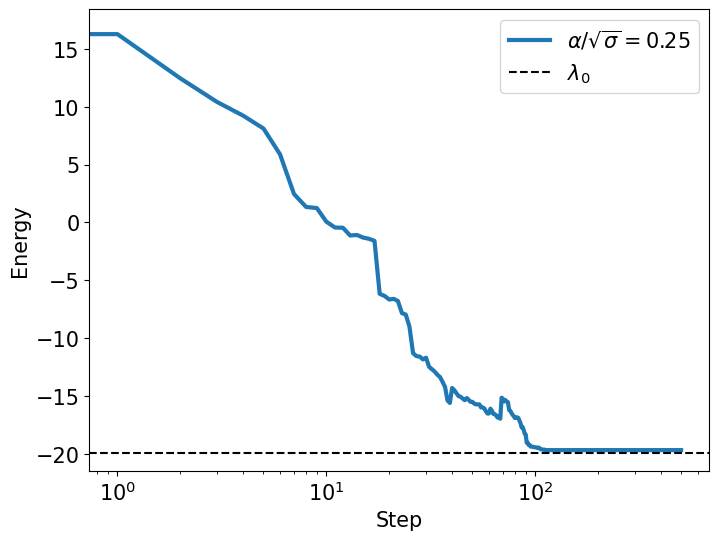

In [8]:
import numpy as np
import matplotlib.pyplot as plt


N = 4 #number of sites in the physical model
dTime = 0.1 #time step size in one iteration
sigma = 4
alpha = 1 / sigma**0.5
Nstep = 1000 #number of iterations
dims = [2] * (N+1) #total system+bath dimension
BB = 5 #maximum bath frequency
np.load_data = np.load("ground_result_TFIM_12.npz")
fidelity = np.load_data["fidelity"]
energy = np.load_data["energy"]

# 2. DMRG Ground State (Target)
L = 12
J = -1.0
g = 1.5
pxx = J
pz = g
Ham_MPO = build_sys_hamiltonian(L, pxx, pz) # Ensure this builds a standard MPO
dmrg = qtn.DMRG2(Ham_MPO)
dmrg.solve(max_sweeps=80, verbosity=0, cutoffs=1e-10)
sys_ground = dmrg.state
sys_ground.normalize() # Ensure norm is 1
minE = qtn.expec_TN_1D(sys_ground.H, Ham_MPO, sys_ground)

plt.figure(figsize=(8,6))
ratio = alpha / np.sqrt(sigma)
plt.plot(energy, linewidth=3, label=fr'$\alpha/\sqrt{{\sigma}} = {ratio:.2f}$')
plt.axhline(y= minE, color='k', linestyle='--', label=r'$\lambda_0$')
plt.xlabel(r'Step', fontsize=15)
plt.ylabel(r'Energy', fontsize=15)
plt.legend(fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xscale('log', base=10)
plt.show()

In [9]:
# # Extra: verify the correctness
# # ==============================================================================
# # RUNNER
# # ==============================================================================

# # ==============================================================================
# # CONFIGURATION
# # ==============================================================================
# inputL = 4
# inputbound = 50
# L = inputL
# max_bond = inputbound
# random.seed(42)

# J = 1.0
# g = 1.5
# pxx = -J
# pz = g
# sigma = 4
# alpha = 1 / sigma**0.5
# Ss = 4 * sigma
# dTime = 0.01
# BB = 5.0
# Nstep = 500

# #0. exact H
# def mkron(ops):
#     """Utility to kronecker a list of matrices."""
#     res = ops[0]
#     for op in ops[1:]:
#         res = np.kron(res, op)
#     return res
# dim = 2**(L)
# H_sys = np.zeros((dim, dim), dtype=complex)
# for i in range(L-1):
#     op = [np.eye(2)]*(L); op[i]=np.array([[0,1],[1,0]]); op[i+1]=op[i]
#     H_sys += pxx * mkron(op)
# for i in range(L):
#     op = [np.eye(2)]*(L); op[i]=np.array([[1,0],[0,-1]])
#     H_sys += pz * mkron(op)
# eigenvals, eigenvecs = np.linalg.eigh(H_sys)
# ground_state = eigenvecs[:,0]
# print("Exact Ground State Energy:", eigenvals[0])
# ## ==============================================================================

# # 2. DMRG Ground State (Target)
# Ham_MPO = build_sys_hamiltonian(L, pxx, pz) # Ensure this builds a standard MPO
# dmrg = qtn.DMRG2(Ham_MPO)
# dmrg.solve(max_sweeps=80, verbosity=0, cutoffs=1e-10)
# sys_ground = dmrg.state
# sys_ground.normalize() # Ensure norm is 1
# minE = qtn.expec_TN_1D(sys_ground.H, Ham_MPO, sys_ground)

# print("DMRG Ground state norm = ", sys_ground.H @ sys_ground)
# print("DMRG Ground state energy = ", minE)

# ## ==============================================================================

# print(f"--- Running Simulation (L={L}, Bond={max_bond}) ---")

# # 3. Initialize State (Pure Vector MPS)
# psi_vec = np.random.randn(2**L) + 1j * np.random.randn(2**L)
# psi_vec /= np.linalg.norm(psi_vec)
# psi_mps = qtn.MatrixProductState.from_dense(psi_vec, dims=[2]*L)
# # psi_mps = sys_ground.copy()

# # ---------------------------------------------------------
# # 4. Device/Dtype Conversions (FIXED)
# # ---------------------------------------------------------

# # Detect device (keep CPU or GPU)
# ref_data = list(psi_mps.tensors)[0].data
# if isinstance(ref_data, torch.Tensor):
#     target_device = ref_data.device
# else:
#     target_device = 'cpu'

# # --- FORCE COMPLEX DTYPE ---
# # Even if the ground state is Real, we must store it as Complex
# # because the gates (exp(-iHt)) are complex.
# target_dtype = torch.complex128

# print(f"Targeting Device: {target_device}, Dtype: {target_dtype}")

# def to_compatible_torch(x):
#     if isinstance(x, torch.Tensor):
#         return x.to(dtype=target_dtype, device=target_device)
#     # Cast numpy to tensor with explicit complex dtype
#     return torch.tensor(np.array(x), dtype=target_dtype, device=target_device)

# # Apply conversions to everything
# psi_mps.apply_to_arrays(to_compatible_torch)
# Ham_MPO.apply_to_arrays(to_compatible_torch)
# sys_ground.apply_to_arrays(to_compatible_torch)


# # 5. Simulation Loop
# expm_cache = {}
# max_cache_size = 4*L + 2
# psi_new = psi_vec.copy()
# data1 = np.zeros(Nstep) # Fidelity
# data2 = np.zeros(Nstep) # Energy

# for n in range(Nstep):
#     # Random parameters for this step
#     omega = random.uniform(0, BB)
#     site_i = random.randint(0, L-1)
#     sign = random.choice([-1, 1])
#     pauli_op = random.randint(1, 3) # 1=X, 2=Y, 3=Z

#     print(f"=== Testing Insertion at Step={n} === site_i={site_i} === pauli_op={pauli_op} === omega={omega:.4f} ===")
#     # A. Time Evolution (Returns size L+1)
#     # Note: We use the VECTOR version now
#     with CodeTimer("Time Evolution"):
#         psi_mps, outcome, expm_cache, max_bond_now = run_vector_mps_step_cached_4th(
#             psi_mps, duration=2*Ss, dt=dTime, L=L,
#             pxx=pxx, pz=pz, omega=omega, alpha=sign*alpha,
#             site_i=site_i, pauli_op=pauli_op, max_bond=max_bond,
#             expm_cache=expm_cache
#         )

#     # Cache management
#     if len(expm_cache) > max_cache_size:
#         # Simple FIFO or random eviction if cache grows too large
#         evicted_key = next(iter(expm_cache))
#         del expm_cache[evicted_key]

#     # C. Observables Calculation (Vector methods)
#     with CodeTimer("Measure Calc"):
#         # 1. Fidelity: |<ground|psi>|^2
#         overlap_tn = sys_ground.H & psi_mps
#         out_inds = overlap_tn.outer_inds()
#         overlap_scalar = overlap_tn.contract(output_inds=out_inds)
#         fidelity = abs(overlap_scalar.item())**2
#         # 2. Energy: <psi|H|psi>
#         psi_safe = psi_mps.copy()

#         # Generate a renaming map for all internal bonds
#         # (This grabs all indices that are NOT physical 'k' indices)
#         rename_map = {}
#         for i in range(psi_safe.L + 1):
#                 # Try renaming standard bond names b0..bL to something unique
#                 old_name = f"b{i}"
#                 new_name = f"safe_b{i}"
#                 rename_map[old_name] = new_name
#         # Apply renaming
#         psi_safe.reindex_(rename_map)
#         # Now calculate energy using the safe MPS
#         # Method: H_psi = H @ psi, then Energy = <psi | H_psi>
#         H_psi = Ham_MPO.apply(psi_safe, compress=True)
#         energy_tn = psi_safe.H & H_psi
#         # Contract safely
#         energy_out_inds = energy_tn.outer_inds()
#         energy_scalar = energy_tn.contract(output_inds=energy_out_inds)
#         energy = energy_scalar.item().real

#     data1[n] = fidelity
#     data2[n] = energy.real # Energy should be real

#     print(f"Step = {n} Vector measure, Outcome = {outcome}, Fidelity = {data1[n]:.6f}, Energy = {data2[n]:.6f}, Max Bond Dim: {max_bond_now}")

#     psi_vec_approx = psi_mps.to_dense().flatten()

#     # exact simulation
#     dim = 2**(L+1)
#     H = np.zeros((dim, dim), dtype=complex)
#     for i in range(site_i):
#         op = [np.eye(2)]*(L+1); op[i]=np.array([[0,1],[1,0]]); op[i+1]=op[i]
#         H += -J * mkron(op)
#     for i in range(site_i+1):
#         op = [np.eye(2)]*(L+1); op[i]=np.array([[1,0],[0,-1]])
#         H += g * mkron(op)
#     bath_op = [np.eye(2)]*(L+1); bath_op[site_i+1]=np.array([[1,0],[0,-1]])
#     H += (-omega/2.0) * mkron(bath_op)
#     for i in range(site_i+2, L):
#         op = [np.eye(2)]*(L+1); op[i]=np.array([[0,1],[1,0]]); op[i+1]=op[i]
#         H += -J * mkron(op)
#     for i in range(site_i+2, L+1):
#         op = [np.eye(2)]*(L+1); op[i]=np.array([[1,0],[0,-1]])
#         H += g * mkron(op)
#     sX = np.array([[0,1],[1,0]]); sY = np.array([[0,-1j],[1j,0]]); sZ = np.array([[1,0],[0,-1]])
#     if pauli_op == 1: S = sX
#     elif pauli_op == 2: S = sY
#     elif pauli_op == 3: S = sZ
#     int_ops = [np.eye(2)]*(L+1); int_ops[site_i]=S; int_ops[site_i+1]=sX
#     H += alpha * mkron(int_ops)
#     if site_i < L-1:
#         op = [np.eye(2)]*(L+1); op[site_i]=np.array([[0,1],[1,0]]); op[site_i+2]=op[site_i]
#         H += -J * mkron(op)
#     psi_tot = insert_dense_reference(psi_new, site_i)
#     # 1. Get eigenvalues (w) and eigenvectors (V)
#     w, V = np.linalg.eigh(H)
#     # 2. Exponentiate the eigenvalues directly (element-wise on the vector)
#     #    and THEN turn them into a diagonal matrix.
#     steps = int(2*Ss / dTime)
#     U = V @ np.diag(np.exp(-1j * w * steps * dTime)) @ V.conj().T
#     psi_new = U @ psi_tot
#     psi_new = dense_measure_and_remove(psi_new, site_i+1, outcome)
#     print("Error", np.min([np.linalg.norm(psi_vec_approx.cpu().numpy() - psi_new),np.linalg.norm(psi_vec_approx.cpu().numpy() + psi_new)]))